In [47]:
# Library imports

import os
import pandas as pd
import matplotlib.pyplot as plt

In [48]:
# Read all model stats

models_folder = os.path.join(os.getcwd(), 'models')
model_stats = {}

for model_name in os.listdir(models_folder):
    model_path = os.path.join(models_folder, model_name)
    if os.path.isdir(model_path):
        csv_path = os.path.join(model_path, 'training_stats.csv')
        if os.path.exists(csv_path):
            model_stats[model_name.replace('__', '/')] = pd.read_csv(csv_path)

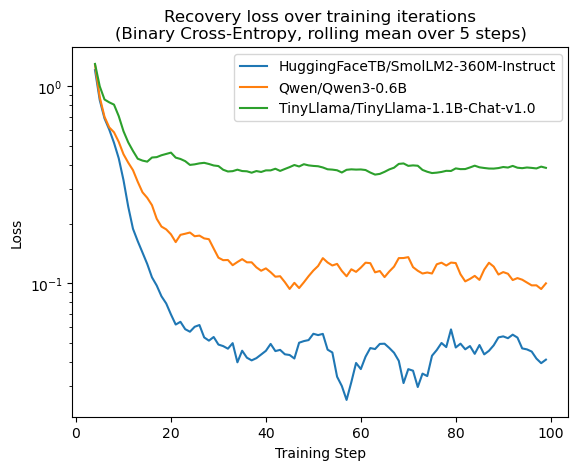

In [49]:
# Plot recovery loss over time
fig, ax1 = plt.subplots()

for model_name, df_stats in model_stats.items():
    ax1.plot(df_stats['step'], df_stats['l_rec'].rolling(window=5).mean(), label=f'{model_name}')

ax1.set_title(f'Recovery loss over training iterations\n(Binary Cross-Entropy, rolling mean over 5 steps)')
ax1.set_yscale('log', base=10)
ax1.set_xlabel('Training Step')
ax1.set_ylabel('Loss')
ax1.legend()

plt.show()

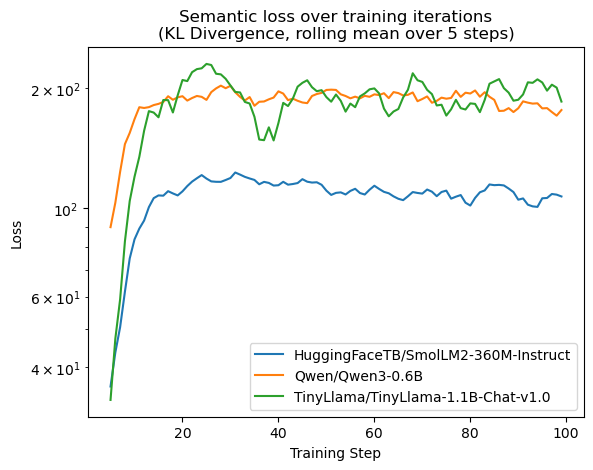

In [50]:
# Plot semantic loss over time
fig, ax1 = plt.subplots()

for model_name, df_stats in model_stats.items():
    df_stats_filtered = df_stats[df_stats['step'] > 0] # Step 0 has l_sem 0, which distorts the plot, so we ignore it for visualization

    plot_sem = ax1.plot(df_stats_filtered['step'], df_stats_filtered['l_sem'].rolling(window=5).mean()
, label=f'{model_name}')

ax1.set_title(f'Semantic loss over training iterations\n(KL Divergence, rolling mean over 5 steps)')
ax1.set_yscale('log', base=10)
ax1.set_xlabel('Training Step')
ax1.set_ylabel('Loss')
ax1.legend()

plt.show()

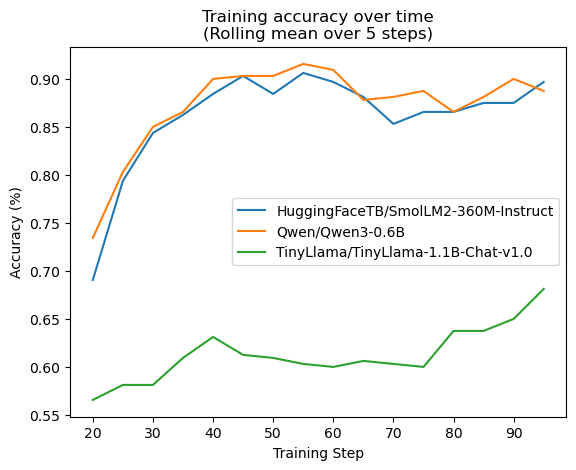

In [51]:
# Plot accuracy over time

fig, ax1 = plt.subplots()

for model_name, df_stats in model_stats.items():
    df_acc = df_stats[df_stats['acc_updated'] == True] # Only plot steps where accuracy was updated (i.e. every 100 steps)
    ax1.plot(df_acc['step'], df_acc['acc'].rolling(window=5).mean(), label=f'{model_name}')

ax1.set_title(f'Training accuracy over time\n(Rolling mean over 5 steps)')
ax1.set_xlabel('Training Step')
ax1.set_ylabel('Accuracy (%)')
ax1.legend()

plt.show()